In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Evaluation
from sklearn.metrics import silhouette_score

In [2]:
# Load dataset
df = pd.read_csv("price_data_sample.csv")

# Display first rows
df.head()

,brand,model,year,price_eur,mileage_km,fuel_type,transmission,power_hp,power_kw,condition,country,seller_type
0,Citroen,C3 Aircross,NaN,15999.0,15985,Petrol,Automatic,NaN,NaN,used,FR,dealer
1,Volkswagen,Arteon,NaN,26749.0,60340,Petrol,Automatic,NaN,NaN,used,DE,dealer
2,Dacia,Duster,NaN,25890.0,1000,Petrol,Automatic,NaN,NaN,used,DE,dealer
3,Fiat,500,NaN,6300.0,91000,Petrol,Manual,NaN,NaN,used,IT,dealer
4,Peugeot,3008,NaN,24995.0,29120,Petrol,Automatic,NaN,NaN,used,BE,dealer


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         30 non-null     str    
 1   model         30 non-null     str    
 2   year          2 non-null      float64
 3   price_eur     30 non-null     float64
 4   mileage_km    30 non-null     int64  
 5   fuel_type     29 non-null     str    
 6   transmission  30 non-null     str    
 7   power_hp      2 non-null      float64
 8   power_kw      1 non-null      float64
 9   condition     30 non-null     str    
 10  country       30 non-null     str    
 11  seller_type   30 non-null     str    
dtypes: float64(4), int64(1), str(7)
memory usage: 4.0 KB


In [4]:
# Select numeric columns
numeric_features = df.select_dtypes(include=['int64','float64'])

numeric_features.head()

,year,price_eur,mileage_km,power_hp,power_kw
0,NaN,15999.0,15985,NaN,NaN
1,NaN,26749.0,60340,NaN,NaN
2,NaN,25890.0,1000,NaN,NaN
3,NaN,6300.0,91000,NaN,NaN
4,NaN,24995.0,29120,NaN,NaN


In [5]:
numeric_features = numeric_features.fillna(
    numeric_features.mean()
)

In [6]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_features)

scaled_data[:5]

array([[ 0.        , -0.27049614, -0.71940431,  0.        ,  0.        ],
       [ 0.        ,  0.04667552, -0.32200252,  0.        ,  0.        ],
       [ 0.        ,  0.02133129, -0.85366349,  0.        ,  0.        ],
       [ 0.        , -0.55665874, -0.04730206,  0.        ,  0.        ],
       [ 0.        , -0.00507509, -0.60172034,  0.        ,  0.        ]])

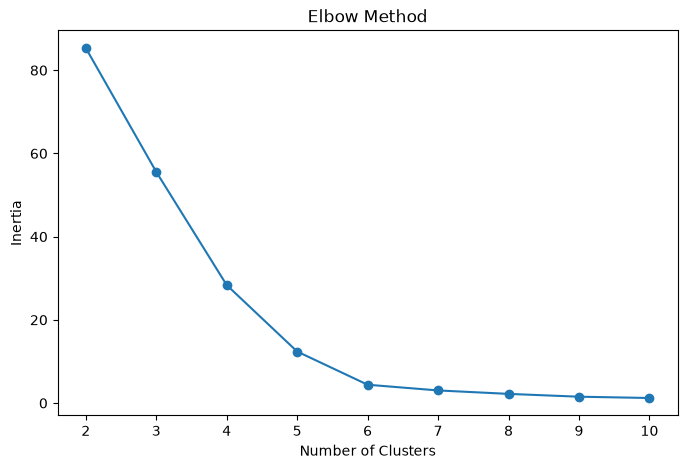

In [7]:
inertia = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df["Price_Cluster"] = clusters

df.head()

,brand,model,year,price_eur,mileage_km,fuel_type,transmission,power_hp,power_kw,condition,country,seller_type,Price_Cluster
0,Citroen,C3 Aircross,NaN,15999.0,15985,Petrol,Automatic,NaN,NaN,used,FR,dealer,0
1,Volkswagen,Arteon,NaN,26749.0,60340,Petrol,Automatic,NaN,NaN,used,DE,dealer,0
2,Dacia,Duster,NaN,25890.0,1000,Petrol,Automatic,NaN,NaN,used,DE,dealer,0
3,Fiat,500,NaN,6300.0,91000,Petrol,Manual,NaN,NaN,used,IT,dealer,0
4,Peugeot,3008,NaN,24995.0,29120,Petrol,Automatic,NaN,NaN,used,BE,dealer,0


In [9]:
df.to_csv(
    "price_data_clustered.csv",
    index=False
)

print("Saved successfully")

Saved successfully
